In [10]:
using LinearAlgebra
using Plots
using Printf
gr()

Plots.GRBackend()

In [2]:
function func(x)
    return 10*x[1]^2 + 0*x[1]*x[2] + x[2]^2 - 10*x[1] + 1
end

func (generic function with 1 method)

In [3]:
function get_exact_gradient(x)
    df_dx1 = 20*x[1] - 10
    df_dx2 = 2*x[2]
    return [df_dx1, df_dx2]
end

get_exact_gradient (generic function with 1 method)

In [5]:
function get_exact_alpha(p, grad)
    A = [20.0 0.0;
         0.0 2.0]
    alpha = -dot(p, grad) / dot(p, A * p)
    return alpha
end

get_exact_alpha (generic function with 1 method)

In [6]:
function bfgs(f, x0; max_iters=100, epsilon=1e-4)
    x = copy(x0)
    trajectory = [copy(x)]
    n = length(x)
    println("x0 = $x0")
    
    H = Matrix{Float64}(I, n, n)
    println("H_0 = $H")
    
    grad = get_exact_gradient(x)
    println("grad_0 = $grad")
    
    for i in 1:max_iters
        println("\nШаг k = $(i-1)")
        temp = norm(grad)
        println("Проверяем критерий остановки: ||grad|| = $(round(temp, digits=6))")
        
        if temp < epsilon
            println("Минимум найден")
            break
        end
        
        p = -H * grad
        println("Направление p = $p")
        
        alpha = get_exact_alpha(p, grad)
        println("Шаг alpha = $(round(alpha, digits=6))")
        
        x_new = x + alpha * p
        println("Новая точка x_new = $(round.(x_new, digits=6))")
        
        grad_new = get_exact_gradient(x_new)
        println("Новый градиент grad_new = $(round.(grad_new, digits=6))")
        
        s = x_new - x
        println("Разность координат delta_x (s) = $(round.(s, digits=6))")
        
        y = grad_new - grad
        println("Разность градиентов delta_g (y) = $(round.(y, digits=6))")
        
        rho = 1.0 / dot(y, s)
        println("Коэффициент rho = $(round(rho, digits=6))")
        
        if isfinite(rho) && rho > 0
            I_n = Matrix{Float64}(I, n, n)
            H = (I_n - rho * s * y') * H * (I_n - rho * y * s') + rho * s * s'
            println("Обновленная матрица H = \n$(round.(H, digits=6))")
        end
        
        x = x_new
        grad = grad_new
        push!(trajectory, copy(x))
    end
    
    return x, trajectory
end

bfgs (generic function with 1 method)

In [7]:
function visualize_bfgs_method(f, name, x0, bounds_pad=2.0)
    println("ФУНКЦИЯ: $name | Старт: $x0")
    
    t1 = time()
    x_bfgs, hist_bfgs = bfgs(f, x0)
    time_bfgs = round(time() - t1, digits=6)
    iters1 = length(hist_bfgs) - 1
    
    println("\nBFGS:")
    println("Итераций = $iters1 | Минимум = $(round.(x_bfgs, digits=4)) | Время = $time_bfgs сек")
    
    all_x1 = [p[1] for p in hist_bfgs]
    all_y1 = [p[2] for p in hist_bfgs]
    
    min_x = minimum(all_x1)
    max_x = maximum(all_x1)
    min_y = minimum(all_y1)
    max_y = maximum(all_y1)
    
    xr = range(min_x - bounds_pad, max_x + bounds_pad, length=100)
    yr = range(min_y - bounds_pad, max_y + bounds_pad, length=100)
    Z = [f([x, y]) for y in yr, x in xr]
    
    p1 = contour(xr, yr, Z, levels=50, color=:grays, fill=false, title="$name (2D)", xlabel="x1", ylabel="x2")
    plot!(p1, all_x1, all_y1, color=:blue, lw=2, marker=:circle, markersize=3, label="BFGS")
    scatter!(p1, [x_bfgs[1]], [x_bfgs[2]], color=:blue, markersize=7, marker=:cross, label="")
    scatter!(p1, [x0[1]], [x0[2]], color=:green, markersize=6, label="")
    
    p2 = surface(xr, yr, Z, color=:grays, alpha=0.5, colorbar=false, title="3D", xlabel="x1", ylabel="x2")
    plot!(p2, all_x1, all_y1, [f(p) for p in hist_bfgs], color=:blue, lw=3, label="BFGS")
    scatter!(p2, [x0[1]], [x0[2]], [f(x0)], color=:green, markersize=5, label="")
    scatter!(p2, [x_bfgs[1]], [x_bfgs[2]], [f(x_bfgs)], color=:blue, markersize=7, marker=:cross, label="")
    
    display(plot(p1, p2, layout=(1,2), size=(1100, 500)))
end

visualize_bfgs_method (generic function with 2 methods)

ФУНКЦИЯ: Вариант 2 | Старт: [1.0, 1.0]
x0 = [1.0, 1.0]
H_0 = [1.0 0.0; 0.0 1.0]
grad_0 = [10.0, 2.0]

Шаг k = 0
Проверяем критерий остановки: ||grad|| = 10.198039
Направление p = [-10.0, -2.0]
Шаг alpha = 0.051793
Новая точка x_new = [0.482072, 0.896414]
Новый градиент grad_new = [-0.358566, 1.792829]
Разность координат delta_x (s) = [-0.517928, -0.103586]
Разность градиентов delta_g (y) = [-10.358566, -0.207171]
Коэффициент rho = 0.185651
Обновленная матрица H = 
[0.050213 -0.010674; -0.010674 1.033722]

Шаг k = 1
Проверяем критерий остановки: ||grad|| = 1.828334
Направление p = [0.03714226758305422, -1.8571133791527117]
Шаг alpha = 0.482692
Новая точка x_new = [0.5, 0.0]
Новый градиент grad_new = [0.0, 0.0]
Разность координат delta_x (s) = [0.017928, -0.896414]
Разность градиентов delta_g (y) = [0.358566, -1.792829]
Коэффициент rho = 0.619753
Обновленная матрица H = 
[0.05 0.0; 0.0 0.5]

Шаг k = 2
Проверяем критерий остановки: ||grad|| = 0.0
Минимум найден

BFGS:
Итераций = 2 | Миним

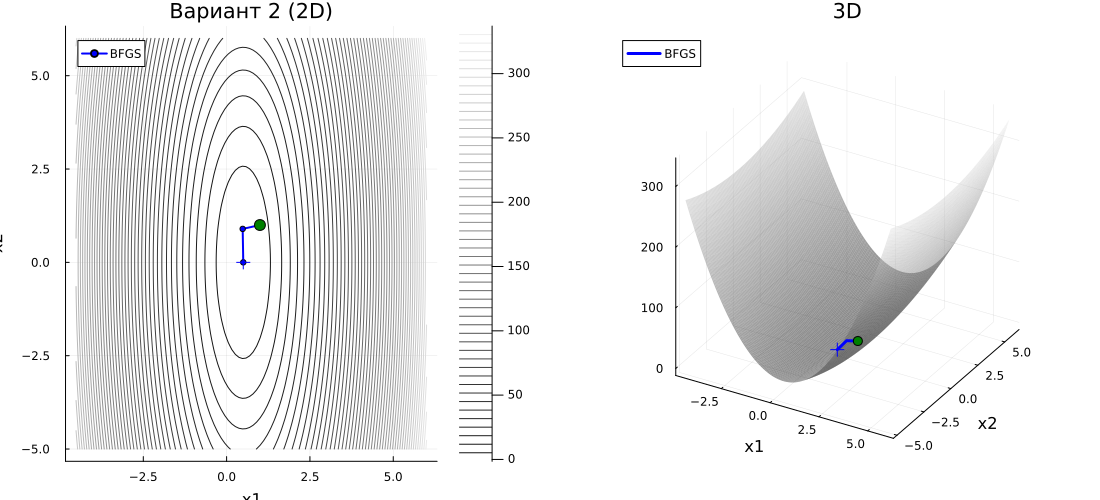

In [11]:
x0_test = [1.0, 1.0]
visualize_bfgs_method(x -> func(x), "Вариант 2", x0_test, 5.0)